In [28]:
import pandas as pd

# Load datasets
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

# Preview
print("Trades Data:")
display(trades.head())

print("\nSentiment Data:")
display(sentiment.head())

Trades Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Sentiment Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [29]:
# Clean column names (VERY IMPORTANT)
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower()

# Check columns
print(trades.columns)
print(sentiment.columns)


Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [30]:
# Convert trade timestamp
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], format='%d-%m-%Y %H:%M')

# Extract date
trades['date'] = trades['timestamp_ist'].dt.date

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Merge datasets
merged = trades.merge(sentiment[['date', 'classification', 'value']], on='date', how='inner')

print("Merged Data:")
display(merged.head())

Merged Data:


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80


In [31]:
merged['sentiment'] = merged['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

In [32]:
pnl_by_sentiment = merged.groupby('sentiment')['closed_pnl'].mean()
print(pnl_by_sentiment)

sentiment
Fear       49.212077
Greed      53.882281
Neutral    34.307718
Name: closed_pnl, dtype: float64


In [33]:
merged['is_profit'] = merged['closed_pnl'] > 0

In [34]:
win_rate = merged.groupby('sentiment')['is_profit'].mean() * 100
print(win_rate)

sentiment
Fear       40.787150
Greed      42.031120
Neutral    39.699093
Name: is_profit, dtype: float64


In [35]:
merged['trade_size'] = merged['size_usd'].abs()

In [36]:
trade_size = merged.groupby('sentiment')['trade_size'].mean()
print(trade_size)

sentiment
Fear       7182.011019
Greed      4574.424490
Neutral    4782.732661
Name: trade_size, dtype: float64


In [37]:
merged['sentiment'] = merged['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'})

In [38]:
fees = merged.groupby('sentiment')['fee'].mean()
print(fees)

sentiment
Fear       1.397763
Greed      0.998166
Neutral    1.044798
Name: fee, dtype: float64


In [39]:
side_analysis = merged.groupby(['sentiment', 'side']).size().unstack()
print(side_analysis)

side         BUY   SELL
sentiment              
Fear       41205  42032
Greed      42516  47779
Neutral    18969  18717


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
merged['sentiment'] = merged['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

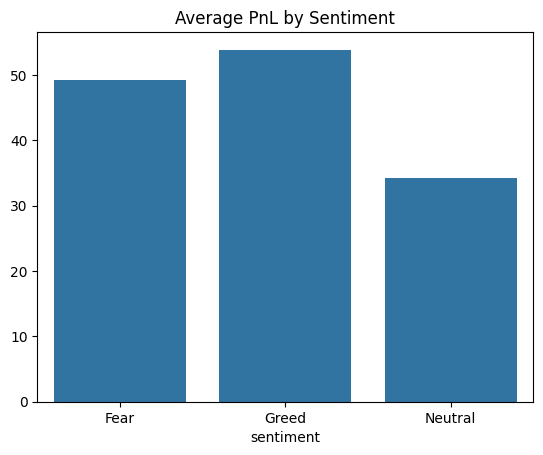

In [42]:
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values)
plt.title("Average PnL by Sentiment")
plt.show()

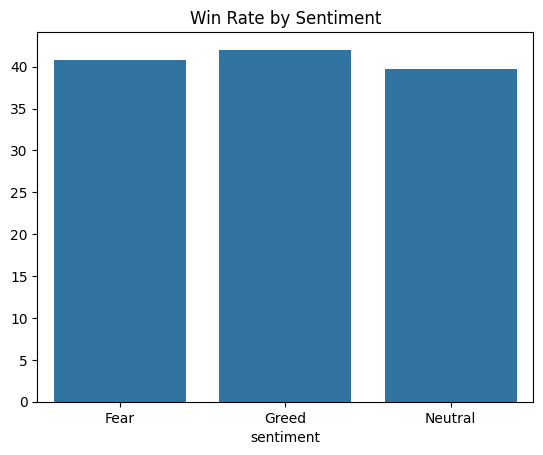

In [43]:
sns.barplot(x=win_rate.index, y=win_rate.values)
plt.title("Win Rate by Sentiment")
plt.show()

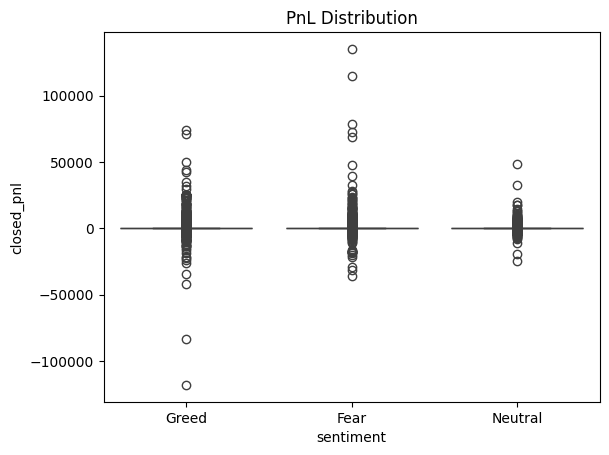

In [44]:
sns.boxplot(x='sentiment', y='closed_pnl', data=merged)
plt.title("PnL Distribution")
plt.show()

In [45]:
merged['sentiment_score'] = merged['value']

In [46]:
merged[['closed_pnl', 'trade_size', 'sentiment_score']].corr()

,closed_pnl,trade_size,sentiment_score
closed_pnl,1.000000,0.123645,0.008121
trade_size,0.123645,1.000000,-0.029843
sentiment_score,0.008121,-0.029843,1.000000


In [47]:
# Feature Engineering (RUN THIS BEFORE ANALYSIS)

merged['is_profit'] = merged['closed_pnl'] > 0
merged['trade_size'] = merged['size_usd'].abs()
merged['sentiment_score'] = merged['value']

merged['sentiment'] = merged['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

In [48]:
merged[['closed_pnl', 'trade_size', 'sentiment_score']].corr()

,closed_pnl,trade_size,sentiment_score
closed_pnl,1.000000,0.123645,0.008121
trade_size,0.123645,1.000000,-0.029843
sentiment_score,0.008121,-0.029843,1.000000


Correlation Analysis

The correlation between sentiment score and closed PnL is very low (~0.008), indicating that sentiment alone does not directly determine profitability.

Trade size shows a slight positive correlation (~0.12) with PnL, suggesting that larger trades may lead to higher profits, but the relationship is weak.

Sentiment score has a slight negative correlation with trade size (~ -0.03), indicating traders do not significantly adjust position size based on sentiment.

INTERPRETATION

This suggests that while market sentiment influences overall trading conditions, individual trader performance is more dependent on strategy and execution rather than sentiment alone.